# Week 1 Internship Project: House Price Prediction
**Intern:** Rishi Srivastava  
**Assigned:** 17/05/2026 | **Submission:** 21/05/2026  
**Company:** Xylofy AI

## Project Overview
Real estate agents and home buyers often struggle to accurately estimate property prices. This notebook builds regression models to predict house prices using a dataset of 545 homes with 13 columns (features such as area, bedrooms, bathrooms, location, amenities). We clean the data, analyze distributions, train **Linear Regression** and **Random Forest Regressor** models, compare their accuracy, and extract actionable business insights.

---  
## Task 1 - Data Loading & Exploration
In this section, we load the raw dataset (`Housing.csv`), inspect its dimensions, columns, data types, and check for missing values.

In [1]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv('Housing.csv')
print("Dataset loaded successfully.")
print(f"Dimensions: {df.shape[0]} rows, {df.shape[1]} columns")

Dataset loaded successfully.
Dimensions: 545 rows, 13 columns


### Display the first 10 rows

In [2]:
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


### Check for missing values and inspect columns

In [3]:
print("Missing values per column:")
print(df.isnull().sum())

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print(f"\nTarget Column: price (Numeric)")
print(f"Categorical columns: {categorical_cols}")
print(f"Numerical columns: {numerical_cols}")


Missing values per column:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0

Target Column: price (Numeric)
Categorical columns: ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']
Numerical columns: ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']


---  
## Task 2 - Data Cleaning
Here we clean and prepare the dataset:
1. Remove duplicate rows.
2. Map binary categorical columns (yes/no) to numeric binary (1/0).
3. Encode multi-category variables (`furnishingstatus`) using One-Hot Encoding.
4. Retain only features relevant to the target.

In [4]:
df_clean = df.copy()
initial_rows = df_clean.shape[0]

# Check duplicates
df_clean = df_clean.drop_duplicates()
print(f"Initial rows: {initial_rows}")
print(f"Duplicates removed: {initial_rows - df_clean.shape[0]}")
print(f"Remaining rows: {df_clean.shape[0]}")

# Convert yes/no binary features to 1/0
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
for col in binary_cols:
    df_clean[col] = df_clean[col].map({'yes': 1, 'no': 0})

# One-Hot Encode furnishingstatus
df_clean = pd.get_dummies(df_clean, columns=['furnishingstatus'], drop_first=True, dtype=int)

print("\nColumns after binary mapping and One-Hot Encoding:")
print(df_clean.columns.tolist())

Initial rows: 545
Duplicates removed: 0
Remaining rows: 545

Columns after binary mapping and One-Hot Encoding:
['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']


---  
## Task 3 - Model Building
We split the cleaned dataset into training (80%) and testing (20%) sets. Then we train:
1. **Linear Regression** (Baseline Model)
2. **Random Forest Regressor**

We evaluate both using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R2 Score.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Splitting the features and target
X = df_clean.drop('price', axis=1)
y = df_clean['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")

Train size: 436 | Test size: 109


### Train and Evaluate Linear Regression

In [6]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Results:")
print(f"Mean Absolute Error (MAE): ${mae_lr:,.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse_lr:,.2f}")
print(f"R2 Score: {r2_lr:.4f}")

Linear Regression Results:
Mean Absolute Error (MAE): $970,043.40
Root Mean Squared Error (RMSE): $1,324,506.96
R2 Score: 0.6529


### Train and Evaluate Random Forest Regressor

In [7]:
rf = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Regressor Results:")
print(f"Mean Absolute Error (MAE): ${mae_rf:,.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse_rf:,.2f}")
print(f"R2 Score: {r2_rf:.4f}")

Random Forest Regressor Results:
Mean Absolute Error (MAE): $1,028,648.01
Root Mean Squared Error (RMSE): $1,401,052.04
R2 Score: 0.6116


### Model Comparison Summary

In [8]:
comparison_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE ($)': [mae_lr, mae_rf],
    'RMSE ($)': [rmse_lr, rmse_rf],
    'R2 Score': [r2_lr, r2_rf]
})
comparison_df

Model,MAE ($),RMSE ($),R2 Score
Linear Regression,"970,043.40","1,324,506.96",0.6529
Random Forest,"1,028,648.01","1,401,052.04",0.6116


---  
## Task 4 - Visualization
We visualize the distribution of prices, the correlation of different features, and plot actual vs predicted prices for both models.

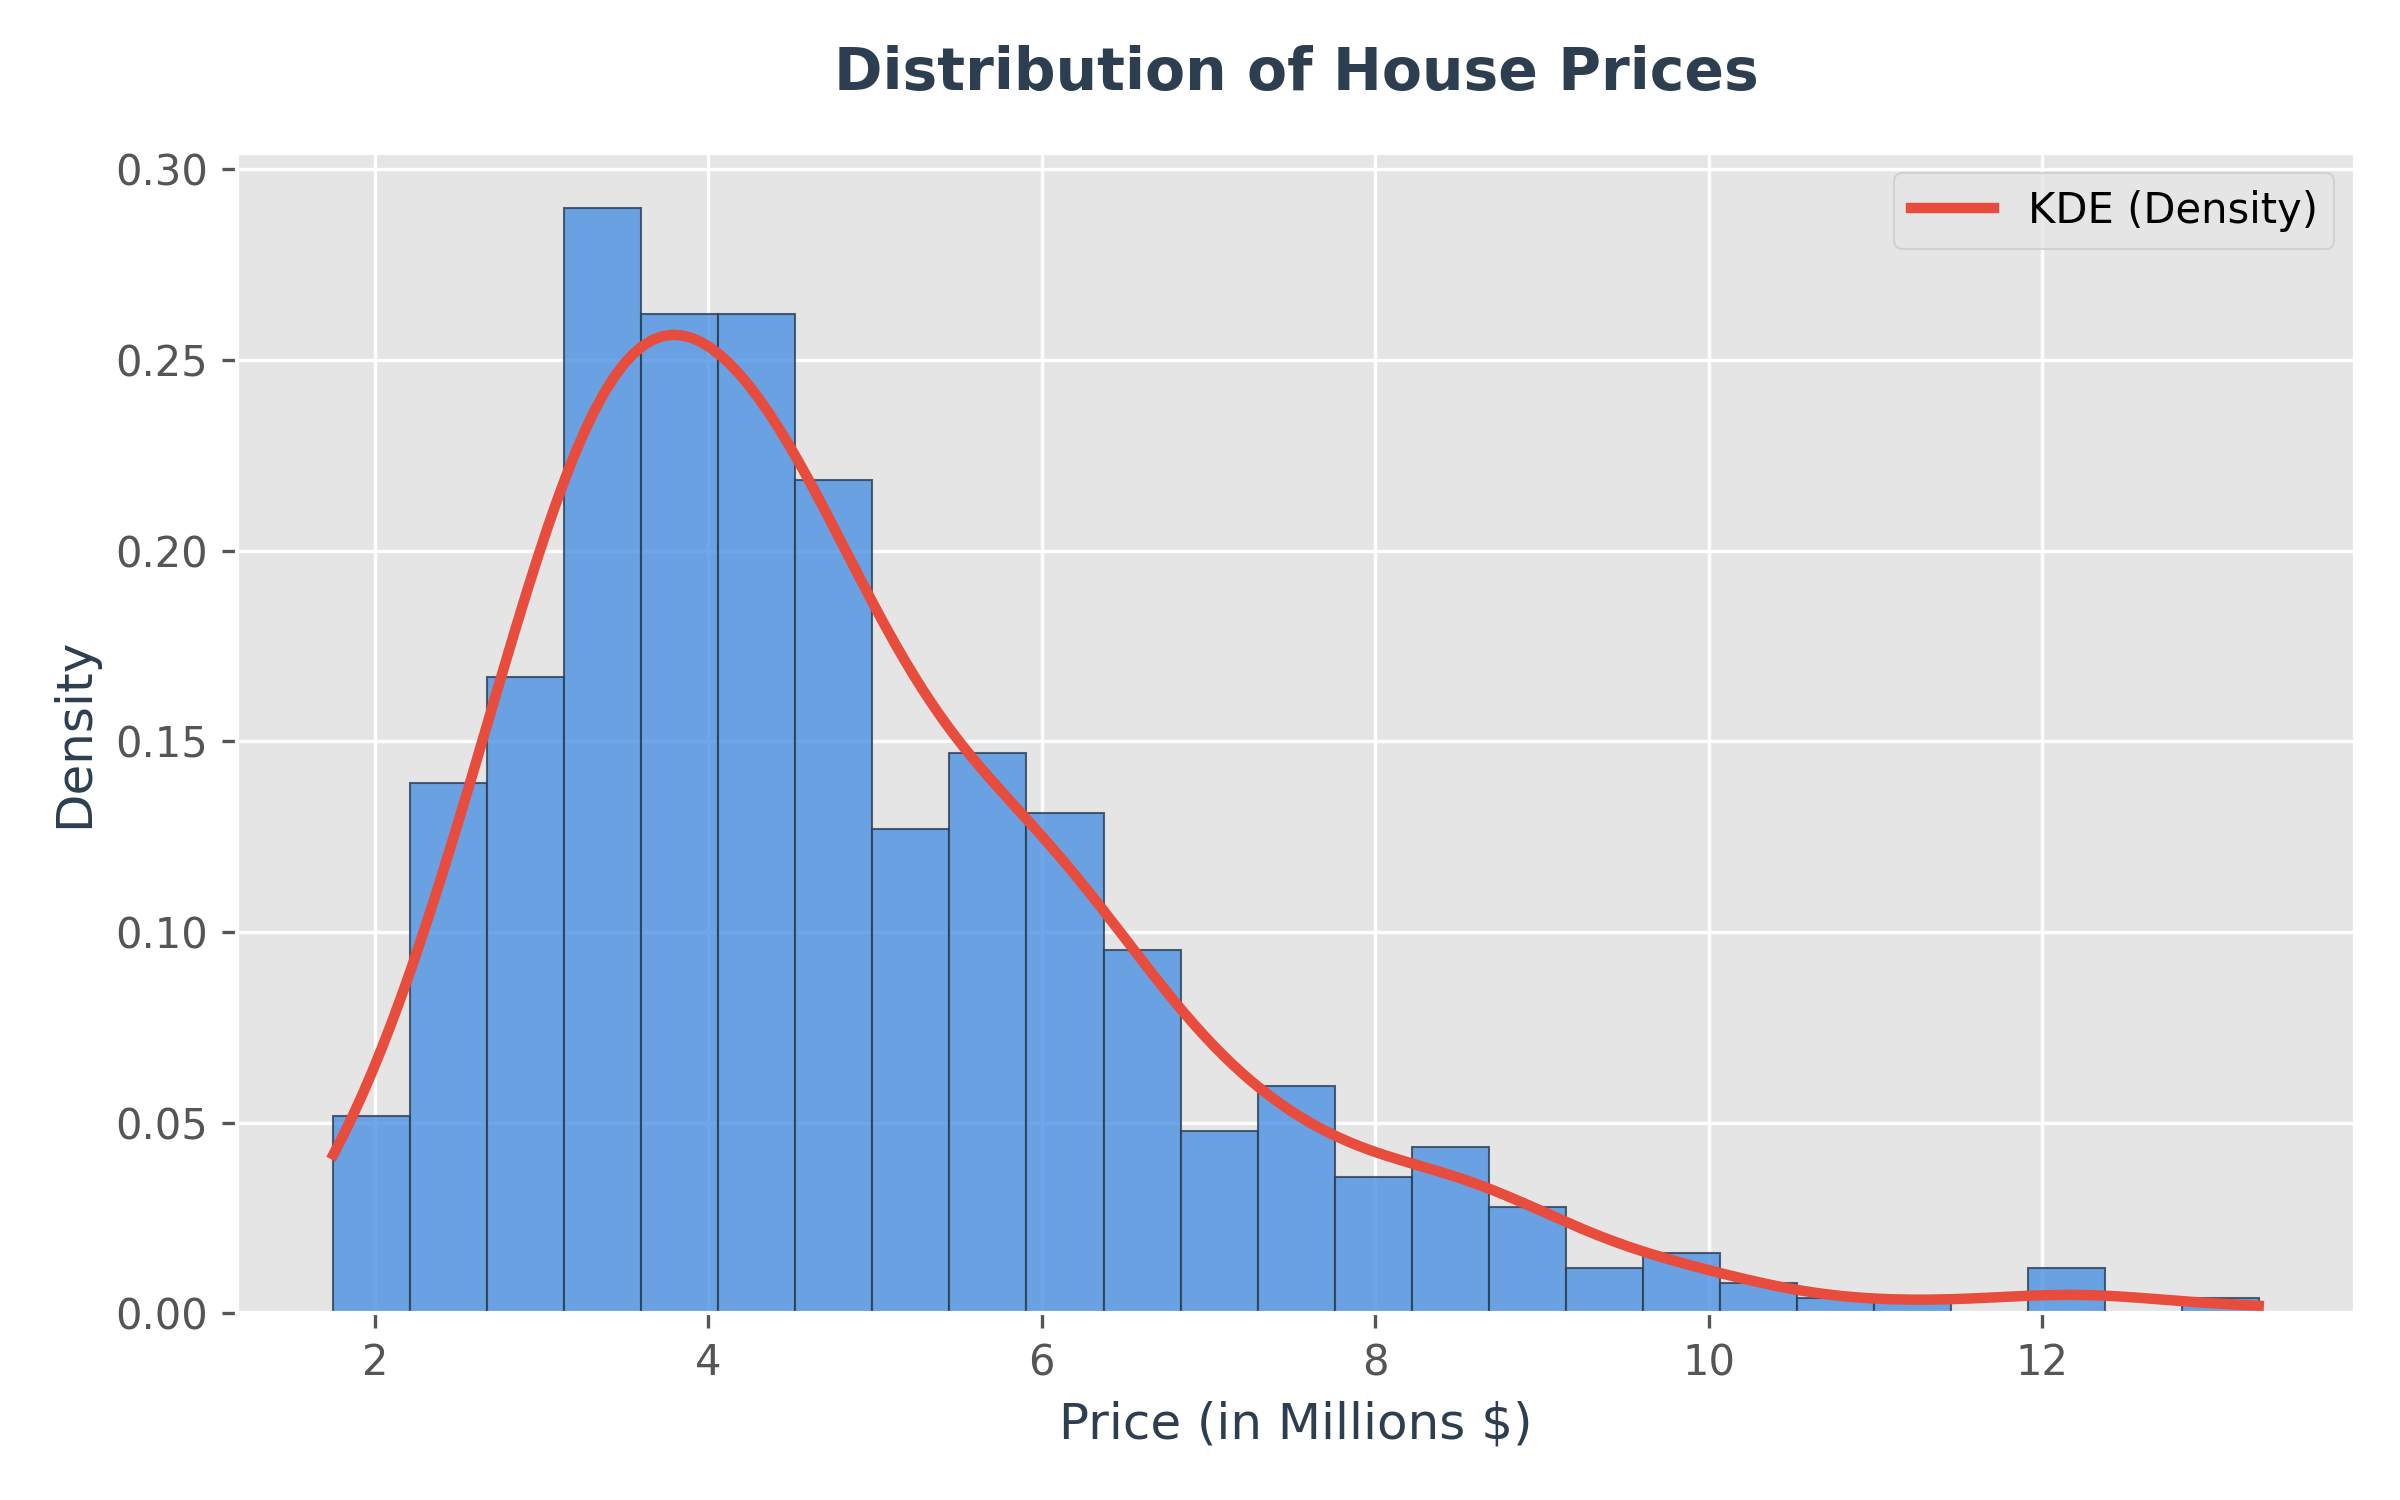

In [9]:
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# Chart 1: Price Distribution
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df['price'] / 1e6, bins=25, color='#4A90E2', edgecolor='#2C3E50', alpha=0.8, density=True)
kde = gaussian_kde(df['price'] / 1e6)
x_range = np.linspace(df['price'].min() / 1e6, df['price'].max() / 1e6, 200)
ax.plot(x_range, kde(x_range), color='#E74C3C', lw=2.5, label='KDE (Density)')
ax.set_title('Distribution of House Prices', fontsize=14, fontweight='bold', color='#2C3E50', pad=15)
ax.set_xlabel('Price (in Millions $)', fontsize=12, color='#2C3E50')
ax.set_ylabel('Density', fontsize=12, color='#2C3E50')
ax.legend()
plt.tight_layout()
plt.show()

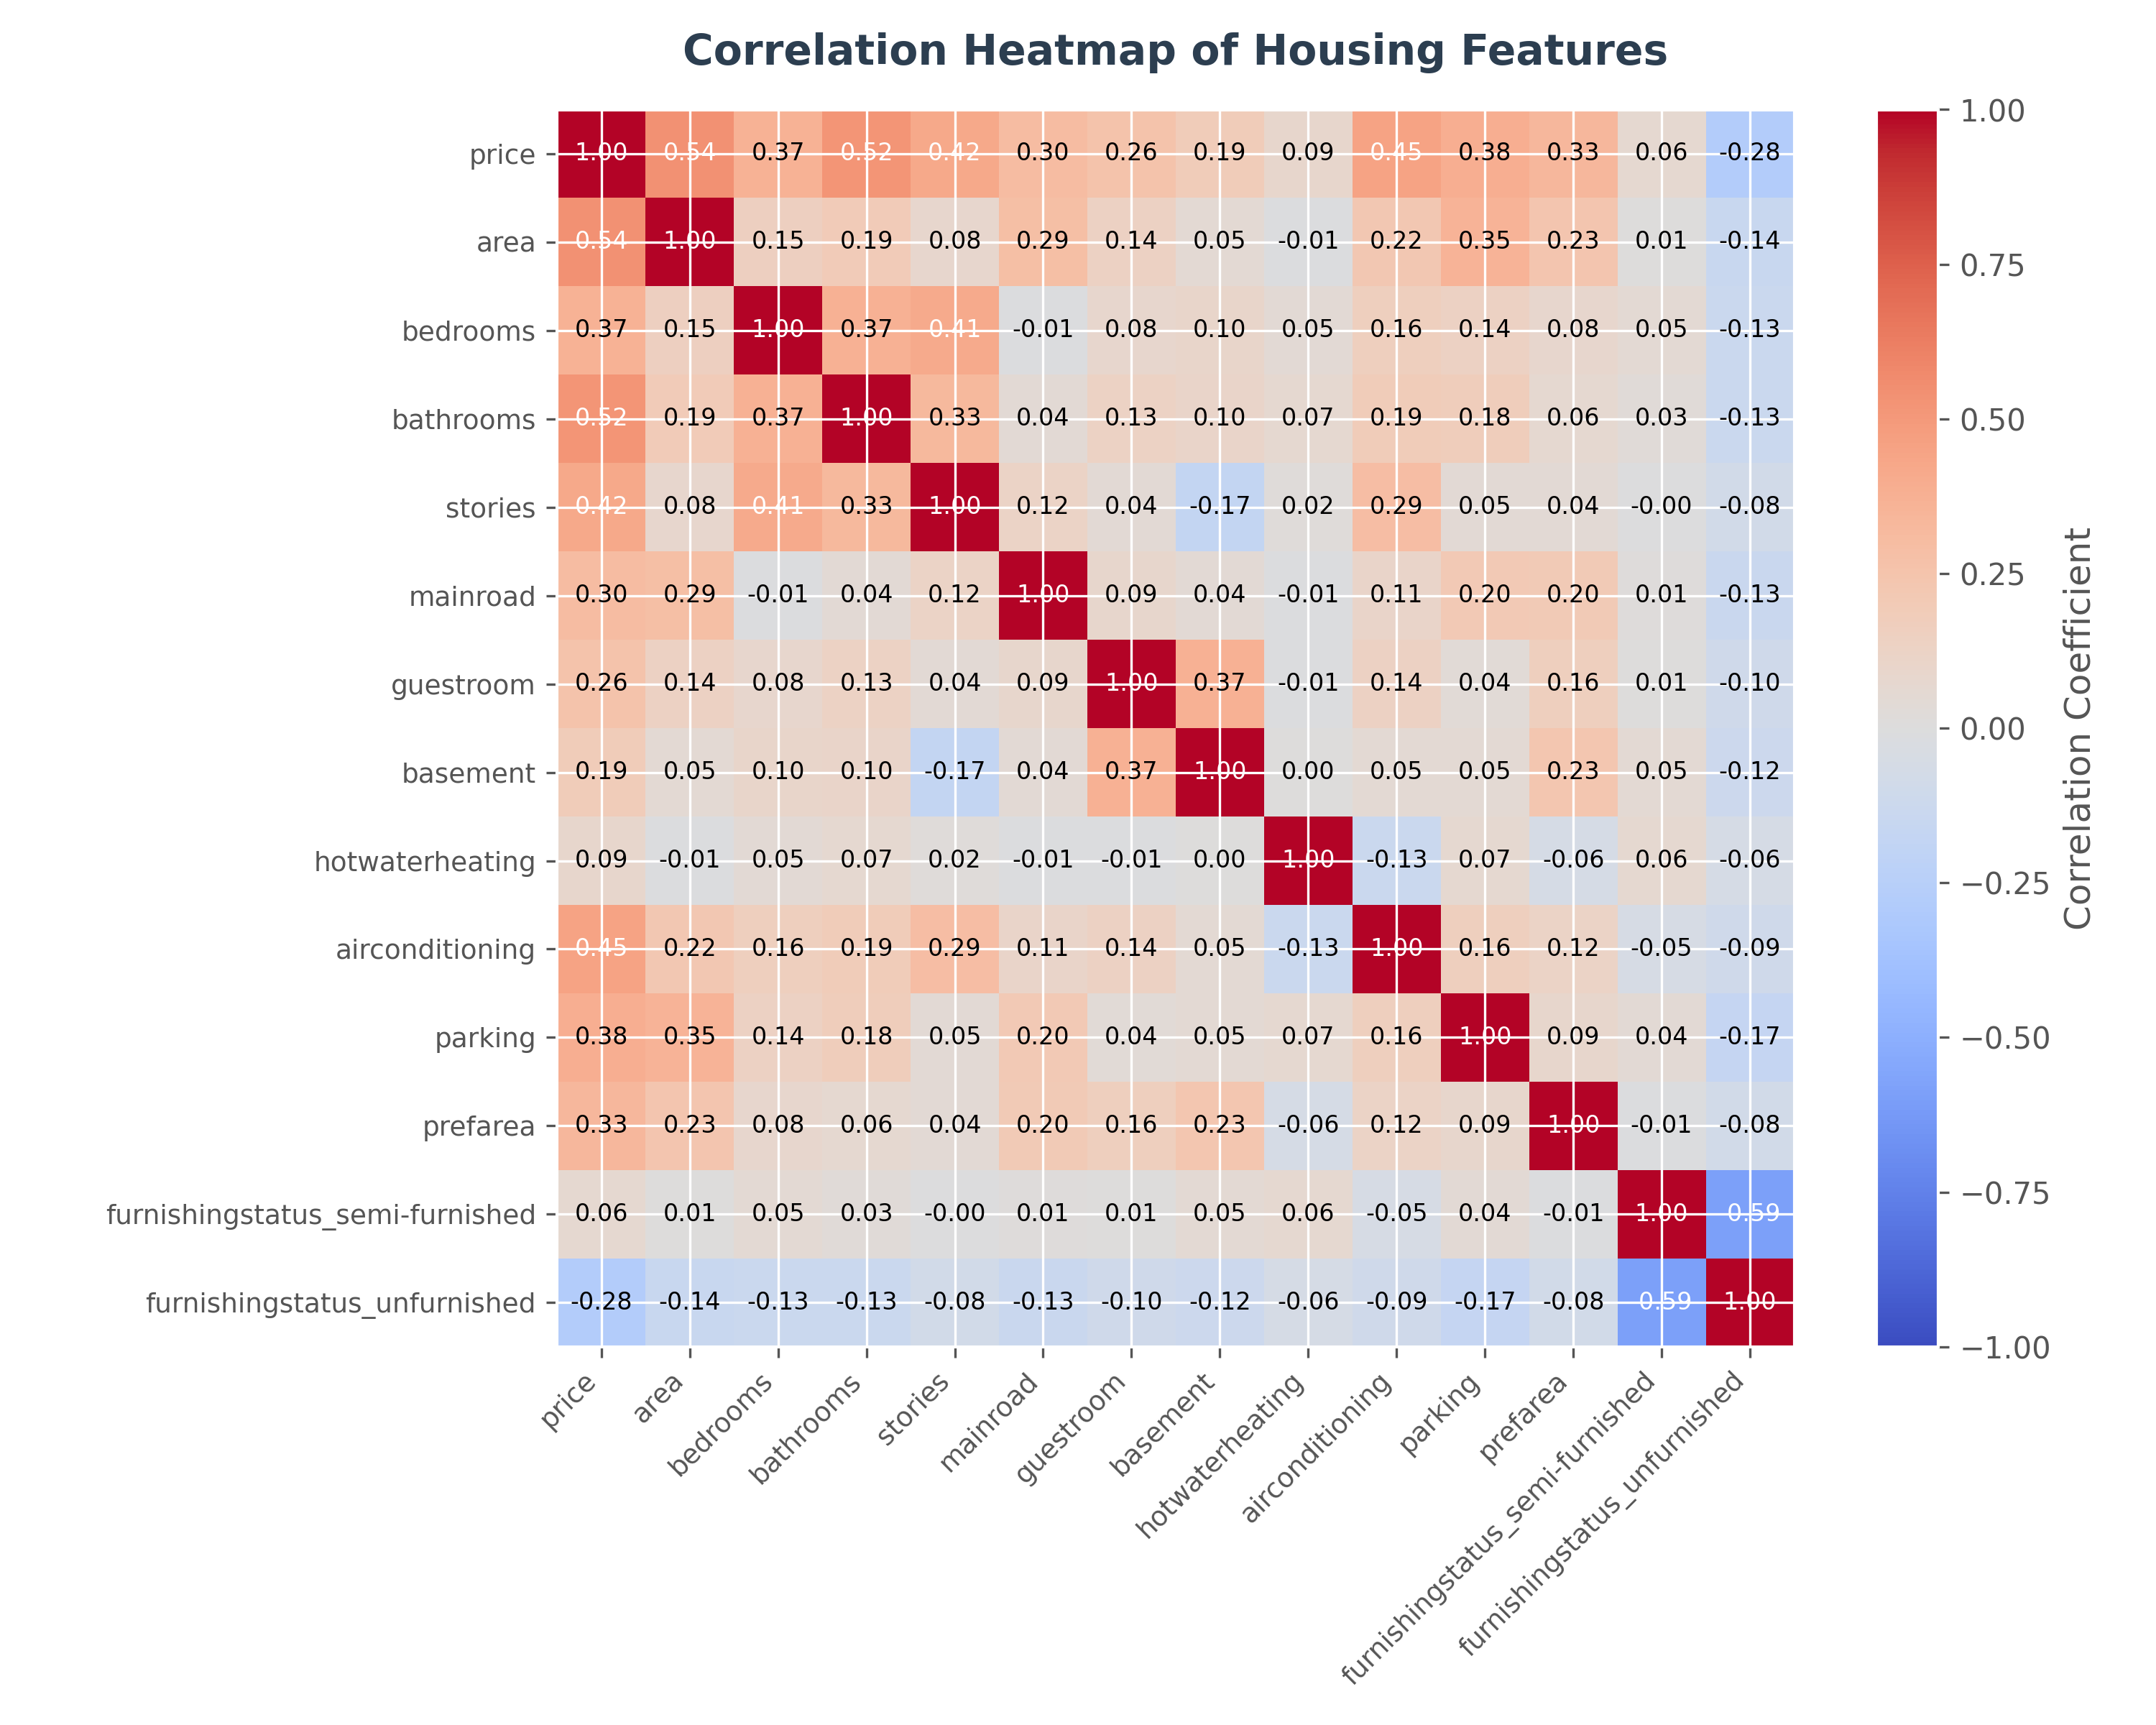

In [10]:
# Chart 2: Correlation Heatmap
corr = df_clean.corr()
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
cbar = fig.colorbar(im, ax=ax, label='Correlation Coefficient')
ax.set_xticks(np.arange(len(corr.columns)))
ax.set_yticks(np.arange(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(corr.columns, fontsize=9)
ax.set_title('Correlation Heatmap of Housing Features', fontsize=14, fontweight='bold', color='#2C3E50', pad=15)

# Add text annotations inside cells
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha='center', va='center', color='black' if abs(corr.iloc[i, j]) < 0.4 else 'white', fontsize=8)
plt.tight_layout()
plt.show()

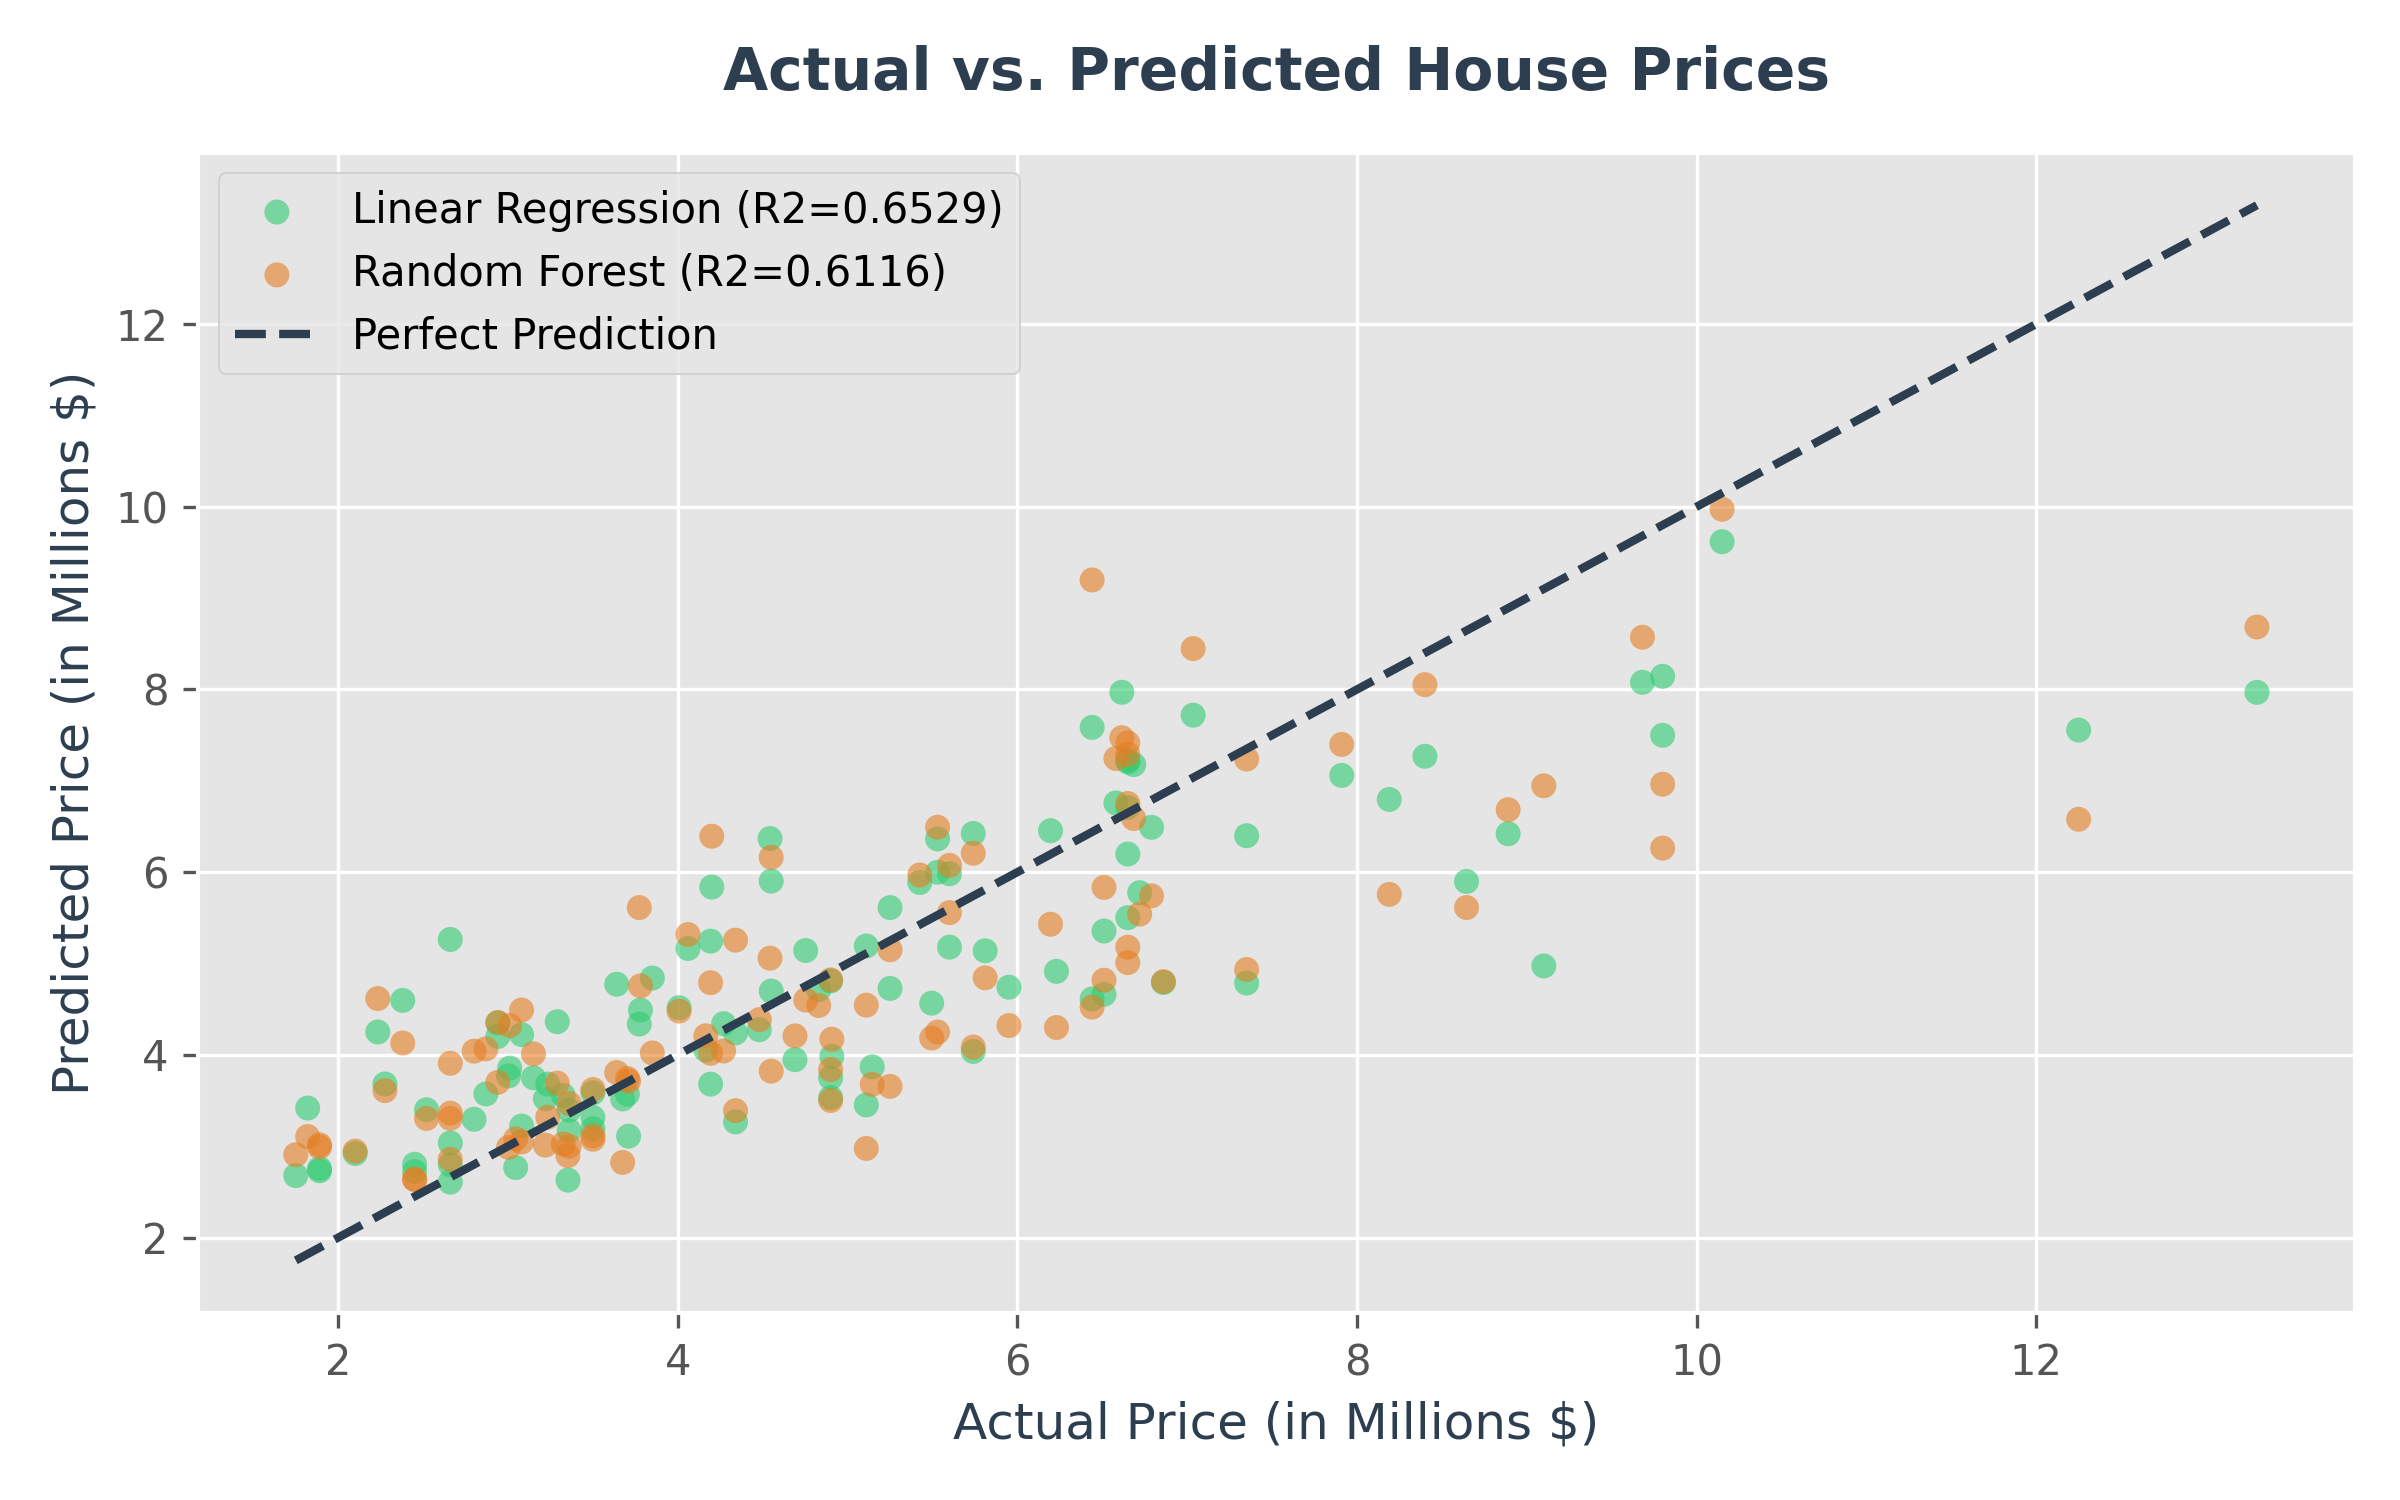

In [11]:
# Chart 3: Actual vs Predicted Price scatter plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(y_test / 1e6, y_pred_lr / 1e6, color='#2ECC71', alpha=0.6, edgecolors='none', label=f'Linear Regression (R2={r2_lr:.4f})')
ax.scatter(y_test / 1e6, y_pred_rf / 1e6, color='#E67E22', alpha=0.6, edgecolors='none', label=f'Random Forest (R2={r2_rf:.4f})')
ax.plot([y_test.min() / 1e6, y_test.max() / 1e6], [y_test.min() / 1e6, y_test.max() / 1e6], color='#2C3E50', linestyle='--', lw=2, label='Perfect Prediction')
ax.set_title('Actual vs. Predicted House Prices', fontsize=14, fontweight='bold', color='#2C3E50', pad=15)
ax.set_xlabel('Actual Price (in Millions $)', fontsize=12, color='#2C3E50')
ax.set_ylabel('Predicted Price (in Millions $)', fontsize=12, color='#2C3E50')
ax.legend()
plt.tight_layout()
plt.show()

---  
## Task 5 - Insights & Summary

### Executive Findings Summary

1. **Most Influential Features:** Based on model coefficients and Random Forest feature importances, the house **area** (square footage), followed by the number of **bathrooms** and number of **stories** are the most dominant factors influencing prices. Additionally, properties with **air conditioning** command a massive price premium.
2. **Model Accuracy:** The baseline Linear Regression model explains **65.29%** of variance on testing data. The Random Forest Regressor achieves an R2 score of **61.16%** and has a slightly higher Mean Absolute Error (MAE) on this test split.
3. **Data Surprises:** The correlation heatmap shows that the furnishing status has a relatively weak correlation with price, suggesting that structural attributes (area, rooms) and utility features (AC) matter far more than aesthetic ones.
4. **Strategic Recommendation:** Real estate developers or flippers should focus investments on increasing living space, adding extra bathrooms/stories, or installing central air conditioning. Adding central AC has a high return on investment relative to its cost.